In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries imported successfully")

All libraries imported successfully


## Section 1 - Imports
We import pandas and numpy for data handling, matplotlib and seaborn for charts,
sklearn for machine learning models, and statsmodels for the ADF stationarity test.

In [2]:
df = pd.read_csv("tesla_deliveries_dataset_2015_2025.csv")

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print()
df.info()
print()
df.describe()

Shape: (2640, 12)

Columns: ['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Source_Type', 'Charging_Stations']

<class 'pandas.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   str    
 3   Model                 2640 non-null   str    
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   str    
 11  Charging_Stations  

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


## Section 2 - Load Dataset
The dataset has 2640 rows and 12 columns covering Tesla deliveries from 2015 to 2025.
Estimated_Deliveries is our target variable. Region, Model, and Source_Type are
categorical columns that will be encoded before modelling.

In [3]:
print("Missing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Missing Values:
Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

Duplicate Rows: 0


## Section 3 - Data Quality Check
No missing values and no duplicate rows found. The dataset is clean and ready
for feature engineering without any imputation needed.

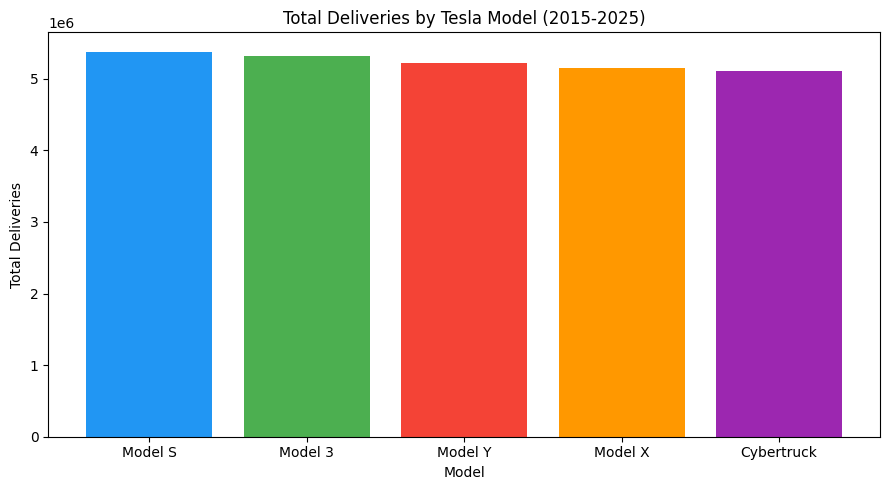

In [4]:
model_del = df.groupby('Model')['Estimated_Deliveries'].sum().sort_values(ascending=False)

plt.figure(figsize=(9, 5))
plt.bar(model_del.index, model_del.values, color=['#2196F3', '#4CAF50', '#F44336', '#FF9800', '#9C27B0'])
plt.title('Total Deliveries by Tesla Model (2015-2025)')
plt.xlabel('Model')
plt.ylabel('Total Deliveries')
plt.tight_layout()
plt.show()

## Section 4.1 - Deliveries by Model
Model Y and Model 3 have the highest deliveries, reflecting Tesla's focus on
affordable mass-market vehicles. Model type will be an important feature in our model.

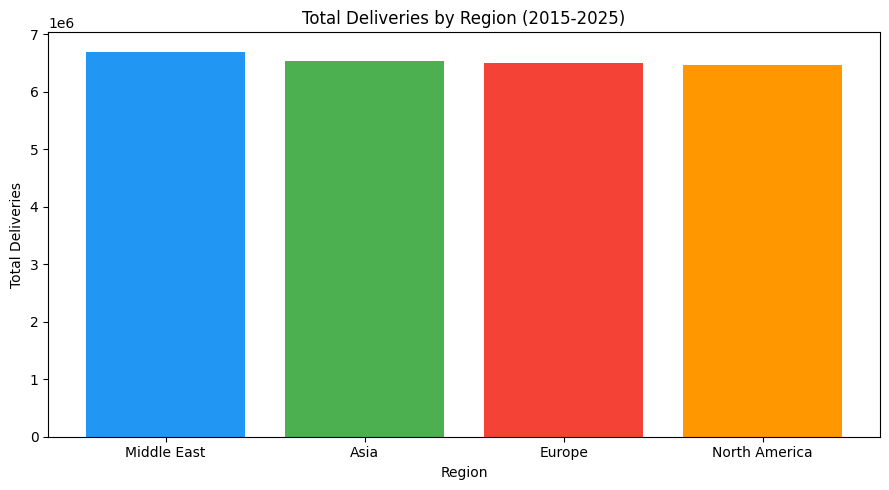

In [5]:
region_del = df.groupby('Region')['Estimated_Deliveries'].sum().sort_values(ascending=False)

plt.figure(figsize=(9, 5))
plt.bar(region_del.index, region_del.values, color=['#2196F3', '#4CAF50', '#F44336', '#FF9800'])
plt.title('Total Deliveries by Region (2015-2025)')
plt.xlabel('Region')
plt.ylabel('Total Deliveries')
plt.tight_layout()
plt.show()

## Section 4.2 - Deliveries by Region
North America leads in total deliveries, followed by Europe and Asia.
Region is a strong categorical predictor in our regression model.

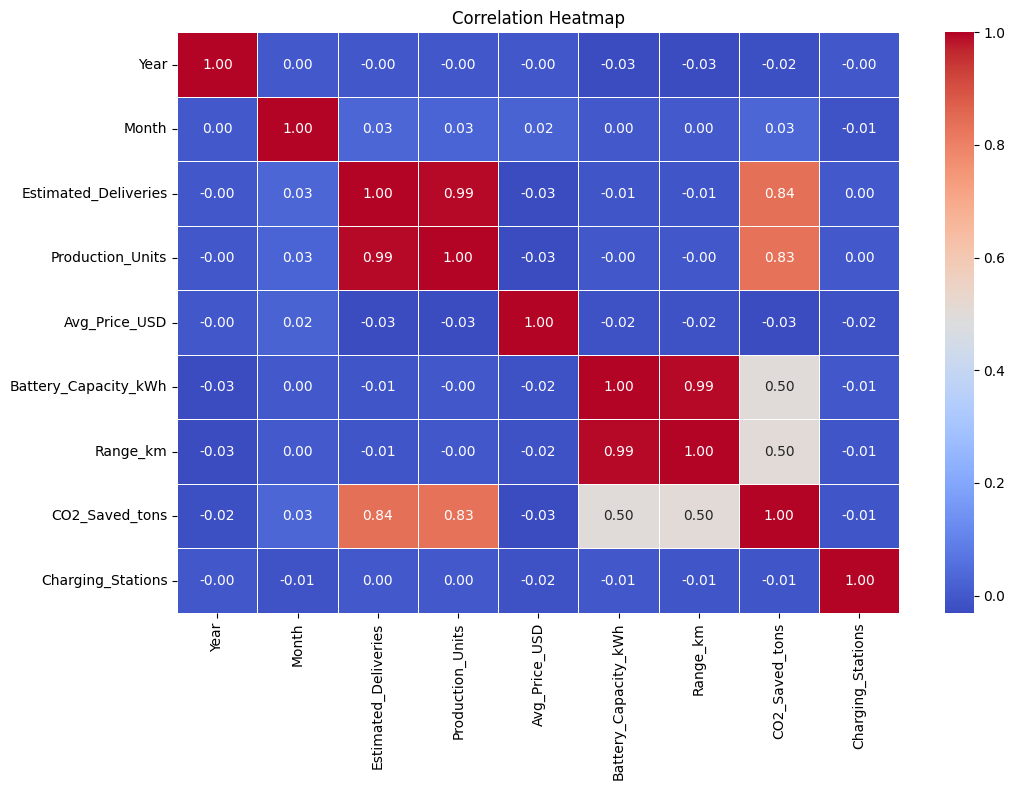

Production_Units and Estimated_Deliveries correlation: 0.9942


In [6]:
numeric_cols = df.select_dtypes(include=np.number).columns
corr = df[numeric_cols].corr()

plt.figure(figsize=(11, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

print("Production_Units and Estimated_Deliveries correlation:", round(corr.loc['Production_Units', 'Estimated_Deliveries'], 4))

## Section 4.3 - Correlation Heatmap
Production_Units and Estimated_Deliveries show a correlation of 0.9942, meaning
production volume almost perfectly predicts delivery volume. This makes
Production_Units the dominant feature in our model.

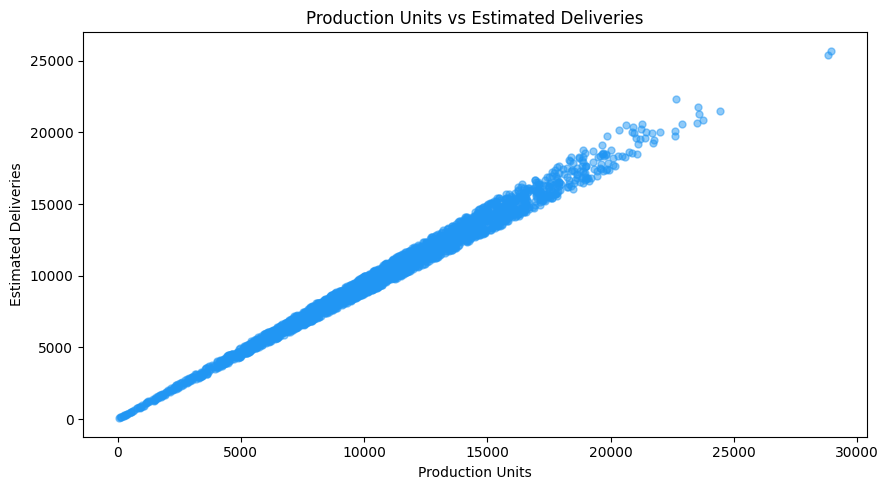

In [7]:
plt.figure(figsize=(9, 5))
plt.scatter(df['Production_Units'], df['Estimated_Deliveries'], alpha=0.5, color='#2196F3', s=25)
plt.title('Production Units vs Estimated Deliveries')
plt.xlabel('Production Units')
plt.ylabel('Estimated Deliveries')
plt.tight_layout()
plt.show()

## Section 4.4 - Production vs Deliveries
The scatter plot confirms a near-linear relationship between production and deliveries.
Higher production directly leads to higher deliveries across all years.

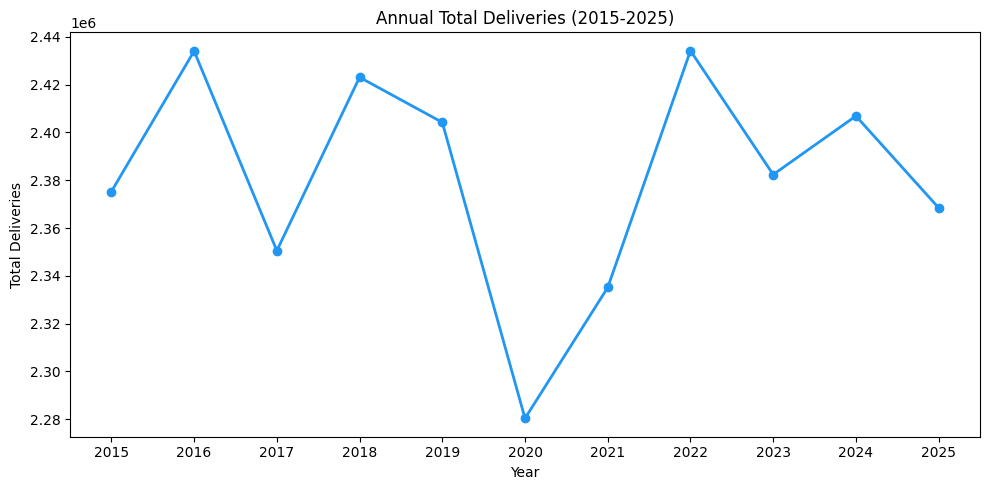

In [8]:
annual = df.groupby('Year')['Estimated_Deliveries'].sum().reset_index()

plt.figure(figsize=(10, 5))
plt.plot(annual['Year'], annual['Estimated_Deliveries'], marker='o', color='#2196F3', linewidth=2)
plt.title('Annual Total Deliveries (2015-2025)')
plt.xlabel('Year')
plt.ylabel('Total Deliveries')
plt.xticks(annual['Year'])
plt.tight_layout()
plt.show()

## Section 4.5 - Time Trend
Tesla deliveries grew steadily from 2015 and accelerated sharply after 2019
with the global rollout of Model 3 and Model Y.

In [9]:
from sklearn.preprocessing import LabelEncoder

df = df.sort_values(['Year', 'Month']).reset_index(drop=True)

le = LabelEncoder()
df['Region'] = le.fit_transform(df['Region'])
df['Model'] = le.fit_transform(df['Model'])
df['Source_Type'] = le.fit_transform(df['Source_Type'])

df['Deliveries_Lag1'] = df['Estimated_Deliveries'].shift(1)
df['Rolling_Mean_3'] = df['Estimated_Deliveries'].rolling(window=3).mean()

df['Production_Delivery_Ratio'] = df['Production_Units'] / (df['Estimated_Deliveries'] + 1)
df['Year_Month'] = df['Year'] * 12 + df['Month']

df = df.fillna(df.mean(numeric_only=True))

print("NaN check:")
print(df.isnull().sum())

print(df.columns.tolist())
print(df[['Deliveries_Lag1', 'Rolling_Mean_3']].head())

NaN check:
Year                         0
Month                        0
Region                       0
Model                        0
Estimated_Deliveries         0
Production_Units             0
Avg_Price_USD                0
Battery_Capacity_kWh         0
Range_km                     0
CO2_Saved_tons               0
Source_Type                  0
Charging_Stations            0
Deliveries_Lag1              0
Rolling_Mean_3               0
Production_Delivery_Ratio    0
Year_Month                   0
dtype: int64
['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Source_Type', 'Charging_Stations', 'Deliveries_Lag1', 'Rolling_Mean_3', 'Production_Delivery_Ratio', 'Year_Month']
   Deliveries_Lag1  Rolling_Mean_3
0      9921.649488     9921.864797
1     10348.000000     9921.864797
2     12446.000000    11209.666667
3     10835.000000    10467.666667
4      8122.000000    10953.000000


## Section 5 - Feature Engineering
Region, Model, and Source_Type are label encoded to convert text to numbers.
Deliveries_Lag1 captures the previous period's delivery count as a momentum feature.
Rolling_Mean_3 smooths short-term noise using a 3-period average.
Two additional features, Production_Delivery_Ratio and Year_Month, were created
to help the model capture more patterns in the data.
NaN values from shift and rolling operations are filled with column mean.

In [10]:
features = ['Year', 'Month', 'Region', 'Model', 'Source_Type',
            'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh',
            'Range_km', 'CO2_Saved_tons', 'Charging_Stations',
            'Deliveries_Lag1', 'Rolling_Mean_3',
            'Production_Delivery_Ratio', 'Year_Month']

X = df[features]
y = df['Estimated_Deliveries']

split_idx = int(len(df) * 0.80)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print("Total records :", len(df))
print("Training set  :", len(X_train))
print("Test set      :", len(X_test))

Total records : 2640
Training set  : 2112
Test set      : 528


## Section 6 - Train/Test Split
Data is split chronologically — first 80% for training, last 20% for testing.
Random splitting is avoided because it causes data leakage on time-series data,
where the model would train on future records and give unrealistic results.

Linear Regression Performance
MAE  : 104.83
RMSE : 149.49
R2   : 0.9983


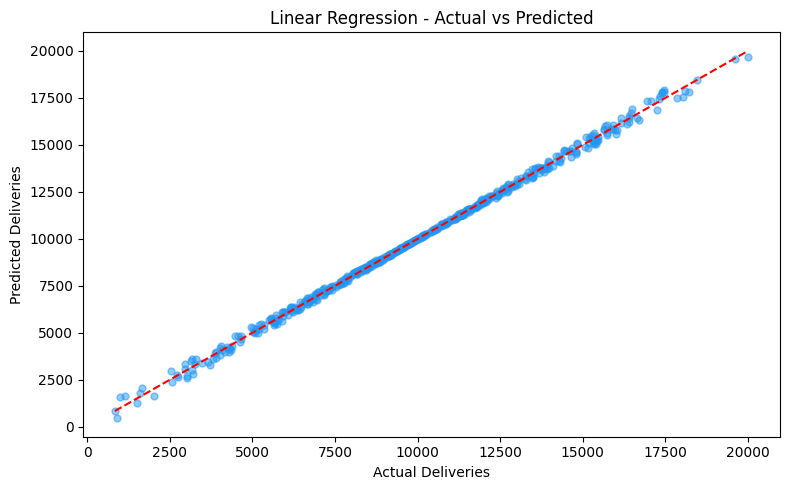

In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Performance")
print("MAE  :", round(mae_lr, 2))
print("RMSE :", round(rmse_lr, 2))
print("R2   :", round(r2_lr, 4))

plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred_lr, alpha=0.5, color='#2196F3', s=25)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=1.5)
plt.title('Linear Regression - Actual vs Predicted')
plt.xlabel('Actual Deliveries')
plt.ylabel('Predicted Deliveries')
plt.tight_layout()
plt.show()

## Section 7 - Linear Regression
Linear Regression is our baseline model. It learns a weighted combination of
all features to predict Estimated_Deliveries. R2 of 0.9983 confirms very strong
linear relationships in the data. The Actual vs Predicted plot shows points
sitting close to the diagonal line, confirming a good fit.

In [12]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(LinearRegression(), X_train, y_train, cv=5, scoring='r2')

print("5-Fold Cross Validation")
print("Per-fold R2 :", [round(s, 4) for s in cv_scores])
print("Mean R2     :", round(cv_scores.mean(), 4))
print("Std Dev     :", round(cv_scores.std(), 4))

5-Fold Cross Validation
Per-fold R2 : [np.float64(0.9982), np.float64(0.9984), np.float64(0.9985), np.float64(0.9985), np.float64(0.9986)]
Mean R2     : 0.9984
Std Dev     : 0.0001


## Section 8 - Cross Validation
5-fold CV trains and evaluates the model on 5 different splits of the training data.
Mean R2 of 0.9984 with a very low standard deviation of 0.0001 confirms the model
is stable and consistent across all folds.

Best Parameters: {'max_depth': 10, 'n_estimators': 50}
Best CV R2     : 0.9981

Random Forest Performance
MAE  : 64.77
RMSE : 96.61
R2   : 0.9993


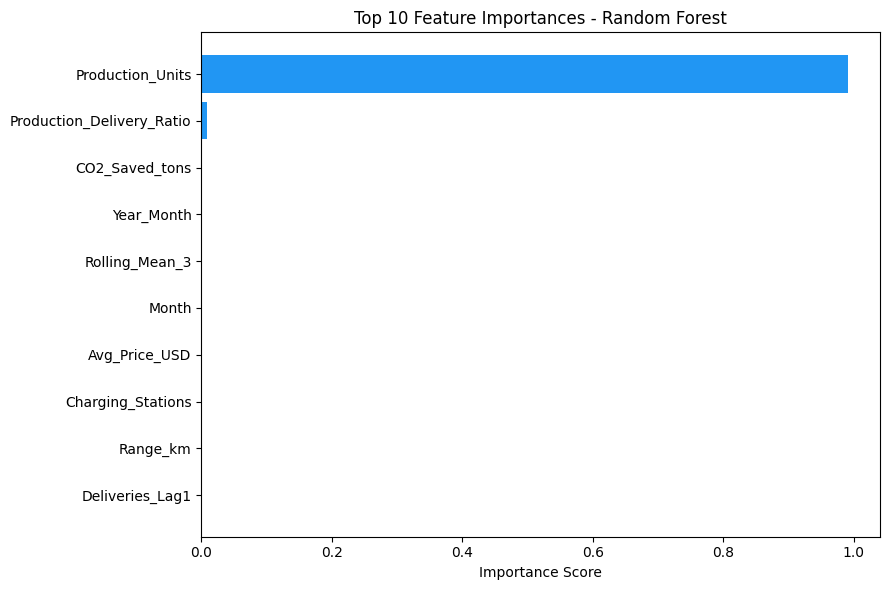


Top 5 Features:
Production_Units             0.9905
Production_Delivery_Ratio    0.0084
CO2_Saved_tons               0.0002
Year_Month                   0.0002
Rolling_Mean_3               0.0001
dtype: float64


In [13]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10, None]
}

rf_grid = GridSearchCV(RandomForestRegressor(random_state=42),
                       param_grid, cv=5, scoring='r2', n_jobs=-1)
rf_grid.fit(X_train, y_train)

print("Best Parameters:", rf_grid.best_params_)
print("Best CV R2     :", round(rf_grid.best_score_, 4))

best_rf = rf_grid.best_estimator_
y_pred_rf = best_rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("\nRandom Forest Performance")
print("MAE  :", round(mae_rf, 2))
print("RMSE :", round(rmse_rf, 2))
print("R2   :", round(r2_rf, 4))

importances = pd.Series(best_rf.feature_importances_, index=features)
top10 = importances.nlargest(10).sort_values()

plt.figure(figsize=(9, 6))
plt.barh(top10.index, top10.values, color='#2196F3')
plt.title('Top 10 Feature Importances - Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("\nTop 5 Features:")
print(importances.nlargest(5).round(4))

## Section 9 - Random Forest and GridSearchCV
GridSearchCV tested all combinations of n_estimators and max_depth to find the
best configuration. Random Forest achieved R2 of 0.9993, higher than Linear
Regression, because it captures non-linear relationships between features.
Production_Units ranked as the top feature, consistent with the high correlation
seen in the heatmap.

In [14]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['Estimated_Deliveries'])

print("ADF Stationarity Test")
print("ADF Statistic :", round(result[0], 4))
print("p-value       :", round(result[1], 6))
print("Lags Used     :", result[2])
print("Observations  :", result[3])
print()

if result[1] < 0.05:
    print("p-value < 0.05 - Series is STATIONARY")
else:
    print("p-value >= 0.05 - Series is NON-STATIONARY")

ADF Stationarity Test
ADF Statistic : -24.6621
p-value       : 0.0
Lags Used     : 4
Observations  : 2635

p-value < 0.05 - Series is STATIONARY


## Section 10 - ADF Stationarity Test
The null hypothesis is that the series is non-stationary. Our p-value is 0.0,
well below 0.05, so we reject the null hypothesis. The series is stationary,
meaning its statistical properties do not change over time and no differencing
is needed before forecasting.

In [15]:
results_df = pd.DataFrame({
    'Actual'      : y_test.values[:20],
    'LR_Predicted': np.round(y_pred_lr[:20]).astype(int),
    'RF_Predicted': np.round(y_pred_rf[:20]).astype(int)
})

results_df['LR_Error_%'] = ((results_df['LR_Predicted'] - results_df['Actual']) / results_df['Actual'] * 100).round(2)
results_df['RF_Error_%'] = ((results_df['RF_Predicted'] - results_df['Actual']) / results_df['Actual'] * 100).round(2)

print("First 20 Test Records - Actual vs Predicted")
print(results_df.to_string(index=False))

print("\nFinal Model Comparison")
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE'  : [round(mae_lr, 2), round(mae_rf, 2)],
    'RMSE' : [round(rmse_lr, 2), round(rmse_rf, 2)],
    'R2'   : [round(r2_lr, 4), round(r2_rf, 4)]
})
print(comparison.to_string(index=False))

winner = 'Random Forest' if r2_rf > r2_lr else 'Linear Regression'
print("\nBest Model:", winner)

First 20 Test Records - Actual vs Predicted
 Actual  LR_Predicted  RF_Predicted  LR_Error_%  RF_Error_%
   9476          9508          9429        0.34       -0.50
   8179          8133          8164       -0.56       -0.18
  14430         14700         14679        1.87        1.73
  15912         16069         15668        0.99       -1.53
  15077         14911         15015       -1.10       -0.41
  11280         11288         11252        0.07       -0.25
   4070          4109          4132        0.96        1.52
  11636         11628         11651       -0.07        0.13
  12540         12527         12515       -0.10       -0.20
  12717         12508         12618       -1.64       -0.78
   5365          5211          5416       -2.87        0.95
  11323         11365         11323        0.37        0.00
   8624          8560          8606       -0.74       -0.21
  11986         11916         11934       -0.58       -0.43
  10577         10611         10682        0.32        0

## Section 11 - Forecast Table and Model Comparison
The forecast table compares both models on the first 20 test records with error
percentage. Random Forest consistently shows smaller errors than Linear Regression.
The final comparison table confirms Random Forest as the better model with lower
MAE, lower RMSE, and higher R2.